## MSA29HCM - Natural Language Processing - Final Project

### Demo: Simple RAG application using different Vector Space Models

#### Group Information

1. Hồ Nhật Thanh - 25MSA23226
2. Bùi Nguyễn Trúc Như - 25MSA23250
3. Nguyễn Văn Nhật - 25MSA23239

### I. Project Overview

#### 1. Introduction and Objectives
The primary objective of this project is to implement, evaluate, and critically compare three distinct classes of Vector Space Models (VSM)—Sparse, Dense, and Contextual models—within a RAG framework for advanced information extraction tasks. By deconstructing the processing pipelines of each model, this project aims to demonstrate a profound mastery of modern retrieval architectures.

#### 2. Model Architectures and Processing Pipelines
To thoroughly understand and master the retrieval process, this project orchestrates three distinct processing pipelines acting upon a unified, domain-specific corpus (an NLP technical document).

* **Phase 1: Data Ingestion and Chunking**

  The raw document is parsed, cleaned, and systematically divided into manageable text chunks using a sliding window approach (e.g., fixed token length with overlap) to ensure that localized context is preserved across boundaries.

* **Phase 2: Sparse Model Pipeline (Lexical Retrieval - BM25)**
  
  This pipeline represents traditional keyword-based search.

  * *Processing*: The corpus undergoes tokenization and normalization. The system builds an Inverted Index, mapping discrete vocabulary terms to their corresponding chunk IDs.

  * *Retrieval*: Upon receiving a query, the model calculates the Okapi BM25 score based on exact term frequency (TF) and inverse document frequency (IDF). It excels at exact-match lookups but is theoretically blind to semantic meaning.

* **Phase 3: Dense Model Pipeline (Semantic Retrieval - Bi-Encoder)**

  This pipeline addresses the vocabulary mismatch problem using deep learning.

  * *Processing*: Both the document chunks and the incoming query are passed independently through a Transformer-based Bi-Encoder (e.g., Sentence-BERT). The text is compressed into high-dimensional, dense floating-point vectors representing latent semantic meaning.

  * *Retrieval*: The system computes the Cosine Similarity between the query vector and all chunk vectors in the multidimensional space, enabling the retrieval of synonymous and conceptually related information.

* **Phase 4: Context Model Pipeline (Single-Stage Cross-Encoder)**
  
  This pipeline serves as the ultimate semantic precision baseline. Unlike industry-standard implementations that use a filtering step, this project intentionally deploys a "naive" or single-stage Cross-Encoder approach to empirically demonstrate both the absolute ceiling of retrieval accuracy and the severe computational limitations of deep learning inference.
  
  * *Processing*: No pre-computation or initial filtering is performed. Upon receiving a query, the system dynamically pairs the query with every single chunk present in the entire document corpus
  
  * *Retrieval*: The Cross-Encoder concatenates the user query and each individual chunk into a single, unified sequence (e.g., [CLS] Query [SEP] Chunk [SEP]). The Transformer's self-attention mechanism performs exhaustive token-level cross-comparisons across the entire dataset, calculating an absolute relevance score for every chunk to extract the definitive Top-K results
  
  * *Architectural Conclusion*: While this pure approach guarantees maximum precision by avoiding the information-loss bottleneck of Dense vectors, it is deliberately implemented to expose the catastrophic latency caused by the $O(L^2)$ time complexity of Transformers. By documenting this extreme execution time, the project mathematically proves the absolute necessity of adopting Two-Stage Retrieval architectures for real-time production systems.

#### **The Computational Imperative of Two-Stage Retrieval**

While the Cross-Encoder provides unparalleled semantic accuracy, applying it directly to an entire database (a Single-Stage approach) is mathematically and computationally unfeasible in production environments.

The core bottleneck lies in the Transformer architecture's self-attention mechanism, which possesses a quadratic time complexity of $O(L^2)$, where $L$ is the combined sequence length of the query and the chunk. Because the query and chunk must be processed simultaneously, Cross-Encoders cannot pre-compute and store document vectors in a database. Evaluating a single query against a modest corpus of 100,000 document chunks would require 100,000 distinct neural network inference passes at runtime, resulting in catastrophic latency (often taking minutes per query).

Therefore, implementing a Two-Stage Retrieval architecture is not merely an optimization, but a strict architectural requirement to balance speed and accuracy:
1. **Stage 1 (High Recall - Asymptotic Speed):**
The system utilizes the Dense or Sparse models (which operate on pre-computed Inverted Indexes or Approximate Nearest Neighbor graphs) to scan millions of records in milliseconds, filtering the corpus down to a small candidate pool (e.g., Top 50 chunks).
2. **Stage 2 (High Precision - Deep Inference):**
The Cross-Encoder acts strictly as a Re-ranker. It executes its computationally expensive cross-attention mechanism only on the 50 candidates retrieved in Stage 1.

This hybrid approach effectively resolves the $O(L^2)$ bottleneck, allowing the RAG system to deliver deep analytical accuracy while strictly adhering to enterprise latency constraints.

#### 3. Testing Methodology
To empirically validate the theoretical behaviors of these models, a simple software testing framework is established. A curated "Ground Truth" dataset comprising varied test scenarios is executed across all three pipelines. The test cases are strategically categorized to expose the strengths and weaknesses of each architecture:

* **Exact Keyword Queries**: To test Sparse model precision.
* **Synonym and Semantic Queries**: To evaluate the Dense model's linguistic mapping.
* **Complex Contextual Traps**: To challenge Bi-Encoders and prove the necessity of Cross-Encoders.
* **Typo Robustness**: To test tokenizer resilience against malformed inputs.
* **Out-of-Domain Queries**: To verify the system's ability to reject irrelevant information.

#### 4. Comparative Evaluation and Conclusions
The final phase of the project involves a quantitative and qualitative analysis of the test results.

* **Quantitative Metrics**: The performance of each model group is benchmarked using standard statistical retrieval metrics, primarily Mean Reciprocal Rank (MRR), to objectively measure ranking accuracy.

* **Architectural Assessment**: The project will analyze the trade-offs between computational latency, memory footprint, and retrieval precision.

### II. Source code

#### 2.1. Data Ingestion and Chunking

- Load sample data

In [1]:
import nltk
import json
import data_ingest
import test

In [2]:
data_path = 'data/NLP_Architecture-of-meaning.pdf'
raw_text = ''

try:
    print("Reading PDF file...")
    raw_text = data_ingest.extract_text_from_pdf(data_path)
    print(f"-> Extraction successful. Text length: {len(raw_text)} characters ({len(raw_text.split())} words).") 
except Exception as e:
    print(f"An error occurred: {e}")

Reading PDF file...
-> Extraction successful. Text length: 28038 characters (3264 words).


- Execute chunking

In [3]:
# try:
#     print("\nPerforming semantic chunking...")
#     chunks = data_ingest.semantic_chunking_by_sentence(raw_text, target_word_count=150, overlap_sentences=1)
#     print(f"-> Split into {len(chunks)} semantic chunks.")
    
#     # Print demo
#     print("\n--- DEMO FIRST 2 CHUNKS ---")
#     for idx, chunk in enumerate(chunks[:2]):
#         print(f"\n[Chunk {idx + 1}] (Length: {len(chunk.split())} words):")
#         print("-" * 50)
#         print(chunk)
#         print("-" * 50)
# except Exception as e:
#     print(f"An error occurred: {e}")

In [4]:
# # 2. Save them to a JSON file
# data_ingest.save_chunks_to_json(
#     chunks=chunks,
#     output_path="data/chunks.json",
#     metadata={"source_file": "NLP_Architecture-of-meaning.pdf", "chunking_method": "sliding_window"}
# )

In [5]:
import data_ingest

# Load chunks and their metadata
chunks, metadata = data_ingest.load_chunks_from_json("data/chunks.json")
print(f"Loaded {len(chunks)} chunks from {metadata.get('source_file', 'unknown')}")

Loaded 25 chunks from NLP_Architecture-of-meaning.pdf


In [6]:
eval_df_path = 'data/eval_dataset.json'

# Load the verified evaluation dataset
with open(eval_df_path, "r", encoding="utf-8") as f:
    eval_dataset = json.load(f)
print(f"Loaded {len(eval_dataset)} test cases successfully!")

Loaded 20 test cases successfully!


#### 2.2. Sparse Model Pipeline

In [7]:
import math
import string
import time
from collections import Counter

def simple_tokenizer(text):
    """
    Tokenize and normalize text by converting to lowercase and removing punctuation.
    """
    text = text.lower()
    # Remove punctuation using translate table
    text = text.translate(str.maketrans("", "", string.punctuation))
    return text.split()


class CustomBM25:
    def __init__(self, corpus, k1=1.5, b=0.75):
        """
        Initialize BM25 index with a corpus of chunks.
        
        Args:
            corpus (list of str): List of document chunks.
            k1 (float): Term frequency saturation tuning parameter (default: 1.5).
            b (float): Document length normalization tuning parameter (default: 0.75).
        """
        self.k1 = k1
        self.b = b
        self.corpus_size = len(corpus)
        
        # Step 1: Tokenization & Normalization
        self.tokenized_corpus = [simple_tokenizer(doc) for doc in corpus]
        
        # Step 2: Calculate document lengths and average document length (avgdl)
        self.doc_lens = [len(doc) for doc in self.tokenized_corpus]
        self.avgdl = sum(self.doc_lens) / self.corpus_size if self.corpus_size > 0 else 0
        
        # Step 3: Compute Term Frequencies (TF) for each document
        self.doc_term_freqs = [Counter(doc) for doc in self.tokenized_corpus]
        
        # Step 4: Build the Inverted Index (term -> list of doc_ids)
        self.inverted_index = {}
        self.df = Counter()  # Document Frequency
        
        for doc_idx, doc in enumerate(self.tokenized_corpus):
            unique_terms = set(doc)
            for term in unique_terms:
                self.df[term] += 1
                if term not in self.inverted_index:
                    self.inverted_index[term] = []
                self.inverted_index[term].append(doc_idx)
                
        # Step 5: Pre-compute Inverse Document Frequency (IDF) using standard Okapi formula
        self.idf = {}
        for term, freq in self.df.items():
            # Standard Okapi BM25 IDF formula
            self.idf[term] = math.log(1 + (self.corpus_size - freq + 0.5) / (freq + 0.5))

    def get_bm25_score(self, query_terms, doc_idx):
        """
        Calculate the Okapi BM25 score for a tokenized query against a specific document.
        """
        score = 0.0
        doc_len = self.doc_lens[doc_idx]
        tf_counter = self.doc_term_freqs[doc_idx]
        
        for term in query_terms:
            if term not in self.idf:
                continue
            
            tf = tf_counter[term]
            idf = self.idf[term]
            
            # Okapi BM25 formula for TF saturation and length normalization
            numerator = tf * (self.k1 + 1)
            denominator = tf + self.k1 * (1 - self.b + self.b * (doc_len / self.avgdl))
            score += idf * (numerator / denominator)
            
        return score

    def retrieve(self, query, corpus, top_k=5):
        """
        Retrieve the top-K chunks relevant to the query.
        
        Returns:
            list of dict: Sorted top-K matches with original indices, scores, and text.
            float: Time taken in seconds.
        """
        start_time = time.time()
        
        # 1. Tokenize query
        query_terms = simple_tokenizer(query)
        
        # 2. Find candidate documents using the Inverted Index (avoid scanning all chunks if score is 0)
        candidate_doc_ids = set()
        for term in query_terms:
            if term in self.inverted_index:
                candidate_doc_ids.update(self.inverted_index[term])
                
        # 3. Calculate scores for candidate documents only
        results = []
        for doc_idx in candidate_doc_ids:
            score = self.get_bm25_score(query_terms, doc_idx)
            results.append({
                "chunk_index": doc_idx,
                "chunk_text": corpus[doc_idx],
                "score": float(score)
            })
            
        # 4. Sort in descending order
        sorted_results = sorted(results, key=lambda x: x["score"], reverse=True)
        
        execution_time = time.time() - start_time
        return sorted_results[:top_k], execution_time


#### 2.3. Dense Model Pipeline

In [8]:
import time
from sentence_transformers import SentenceTransformer, util

class DenseRetriever:
    def __init__(self, model_name="sentence-transformers/all-MiniLM-L6-v2"):
        """
        Initialize and load the pre-trained Bi-Encoder model.
        We use 'all-MiniLM-L6-v2' which is fast, lightweight, and generates 384-dimensional embeddings.
        """
        # Load the model (avoid reloading if already instantiated)
        print(f"Loading Bi-Encoder model: '{model_name}'...")
        self.model = SentenceTransformer(model_name)
        self.chunk_embeddings = None
        print("Model loaded successfully.")
        
    def index_corpus(self, chunks):
        """
        Offline Phase: Pre-compute and store embeddings for all chunks in the corpus.
        """
        start_time = time.time()
        print(f"Encoding {len(chunks)} document chunks into dense vectors...")
        
        # Pre-compute embeddings (we convert to PyTorch tensors for fast matrix operations)
        self.chunk_embeddings = self.model.encode(chunks, convert_to_tensor=True)
        
        duration = time.time() - start_time
        print(f"-> Indexing completed in {duration:.4f} seconds.")
        print(f"-> Embedding space shape: {list(self.chunk_embeddings.shape)} (Chunks x Dimensions)")
        
    def retrieve(self, query, corpus, top_k=5):
        """
        Online Phase: Embed the query at runtime and compute Cosine Similarity against indexed chunks.
        """
        if self.chunk_embeddings is None:
            raise ValueError("Corpus has not been indexed. Please run index_corpus(chunks) first.")
            
        start_time = time.time()
        
        # 1. Generate dense vector for the query
        query_embedding = self.model.encode(query, convert_to_tensor=True)
        
        # 2. Compute Cosine Similarity between the query vector and all stored chunk vectors
        # util.cos_sim performs efficient GPU/CPU matrix multiplication
        cos_scores = util.cos_sim(query_embedding, self.chunk_embeddings)[0]
        
        # 3. Package results
        results = []
        for idx, score in enumerate(cos_scores):
            results.append({
                "chunk_index": idx,
                "chunk_text": corpus[idx],
                "score": float(score)
            })
            
        # 4. Sort by Cosine Similarity score in descending order
        sorted_results = sorted(results, key=lambda x: x["score"], reverse=True)
        
        execution_time = time.time() - start_time
        return sorted_results[:top_k], execution_time


e:\GitHub\finalproject.mlops.group9.msa29hcm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### 2.4. Context Model Pipeline - Cross-Encoder

In [9]:
import time
from sentence_transformers import CrossEncoder

def initialize_cross_encoder(model_name="cross-encoder/ms-marco-MiniLM-L-6-v2"):
    """
    Initialize and load a pre-trained Cross-Encoder model.
    """
    print(f"Loading Cross-Encoder model: '{model_name}'...")
    # The model will be downloaded automatically if not already cached
    model = CrossEncoder(model_name)
    print("Model loaded successfully.")
    return model


def single_stage_cross_encoder_retrieval(query, chunks, model, top_k=5):
    """
    Perform single-stage retrieval by pairing the query with ALL chunks
    and predicting relevance scores using the Cross-Encoder.
    
    Args:
        query (str): The search query.
        chunks (list of str): All document chunks in the corpus.
        model (CrossEncoder): The loaded CrossEncoder model.
        top_k (int): Number of top results to return.
        
    Returns:
        list of dict: Top-K chunks with their scores, original indices, and text.
        float: Time taken in seconds.
    """
    start_time = time.time()
    
    # 1. Dynamically pair the query with EVERY single chunk in the entire corpus
    # Format required by Cross-Encoder: [[query, chunk_1], [query, chunk_2], ...]
    pairs = [[query, chunk] for chunk in chunks]
    
    # 2. Compute absolute relevance scores using the self-attention mechanism
    print(f"Evaluating query against {len(chunks)} chunks using Cross-Encoder...")
    scores = model.predict(pairs)
    
    # 3. Package results with their original indices and scores
    results = []
    for idx, (chunk, score) in enumerate(zip(chunks, scores)):
        results.append({
            "chunk_index": idx,
            "chunk_text": chunk,
            "score": float(score)
        })
        
    # 4. Sort the results by score in descending order
    sorted_results = sorted(results, key=lambda x: x["score"], reverse=True)
    
    execution_time = time.time() - start_time
    
    return sorted_results[:top_k], execution_time

def two_stage_cross_encoder_retrieval(query, corpus, stage1_retriever, stage2_model, stage1_top_k=10, stage2_top_k=3):
    """
    Two-Stage Retrieval Pipeline:
    - Stage 1: Fast retrieval (BM25 or Bi-Encoder) to get 'stage1_top_k' candidates.
    - Stage 2: Cross-Encoder to re-rank the candidates and return top 'stage2_top_k' results.
    
    Args:
        query (str): The search query.
        corpus (list of str): The entire corpus of text chunks.
        stage1_retriever: An instance of CustomBM25 or DenseRetriever.
        stage2_model: An initialized CrossEncoder model.
        stage1_top_k (int): Number of candidates to retrieve in Stage 1.
        stage2_top_k (int): Final number of results to return after re-ranking.
        
    Returns:
        tuple: (list of dict, dict) -> (reranked_results, latency_breakdown)
    """
    import time
    
    # --- STAGE 1: Fast Retrieval ---
    start_stage1 = time.time()
    candidates, stage1_time = stage1_retriever.retrieve(query, corpus, top_k=stage1_top_k)
    
    if not candidates:
        return [], {"stage1_seconds": stage1_time, "stage2_seconds": 0.0, "total_seconds": stage1_time}
        
    # --- STAGE 2: Cross-Encoder Re-ranking ---
    start_stage2 = time.time()
    
    # Format query-chunk pairs only for the retrieved candidates
    pairs = [[query, item["chunk_text"]] for item in candidates]
    
    # Run the Cross-Encoder model on the subset of candidates
    scores = stage2_model.predict(pairs)
    
    # Combine scores with original chunk index and text
    reranked_results = []
    for idx, (candidate, score) in enumerate(zip(candidates, scores)):
        reranked_results.append({
            "chunk_index": candidate["chunk_index"],
            "chunk_text": candidate["chunk_text"],
            "stage1_score": candidate["score"],
            "score": float(score)  # Re-ranked score
        })
        
    # Sort by the new Cross-Encoder score in descending order
    reranked_results = sorted(reranked_results, key=lambda x: x["score"], reverse=True)
    
    stage2_time = time.time() - start_stage2
    total_time = stage1_time + stage2_time
    
    latency_breakdown = {
        "stage1_seconds": stage1_time,
        "stage2_seconds": stage2_time,
        "total_seconds": total_time
    }
    
    return reranked_results[:stage2_top_k], latency_breakdown

#### 2.5. Testing

In [10]:
# Enable the autoreload extension
%load_ext autoreload

# Reload all modules before executing a new line of code
%autoreload 2


In [12]:
print("Checking and preparing retrieval models...")

if 'chunks' not in locals():
    raise NameError("Lỗi: Không tìm thấy biến 'chunks'. Hãy chạy các cell Phase 1 ở phía trên trước.")

if 'eval_dataset' not in locals():
    raise NameError("Lỗi: Không tìm thấy biến 'eval_dataset'. Hãy chạy cell Load Dataset ở phía trên trước.")

# Tự động khởi tạo Custom BM25 Index nếu chưa có trong bộ nhớ
if 'bm25_index' not in locals():
    print("- Initializing Custom BM25 Index...")
    bm25_index = CustomBM25(chunks)

# Tự động khởi tạo Dense Bi-Encoder nếu chưa có trong bộ nhớ
if 'dense_retriever' not in locals():
    print("- Initializing Dense Bi-Encoder...")
    dense_retriever = DenseRetriever("sentence-transformers/all-MiniLM-L6-v2")
    dense_retriever.index_corpus(chunks)

# Tự động khởi tạo Cross-Encoder nếu chưa có trong bộ nhớ
if 'ce_model' not in locals():
    print("- Initializing Cross-Encoder...")
    ce_model = initialize_cross_encoder("cross-encoder/ms-marco-MiniLM-L-6-v2")


Checking and preparing retrieval models...
- Initializing Custom BM25 Index...
- Initializing Dense Bi-Encoder...
Loading Bi-Encoder model: 'sentence-transformers/all-MiniLM-L6-v2'...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 15472.70it/s]


Model loaded successfully.
Encoding 25 document chunks into dense vectors...
-> Indexing completed in 0.3164 seconds.
-> Embedding space shape: [25, 384] (Chunks x Dimensions)
- Initializing Cross-Encoder...
Loading Cross-Encoder model: 'cross-encoder/ms-marco-MiniLM-L-6-v2'...


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 12511.77it/s]


Model loaded successfully.


In [15]:
import evaluation

# --- 1. Chạy đánh giá từng mô hình (Đo Latency, tính MRR và Accuracy@1) ---
print("Evaluating BM25 (Sparse)...")
bm25_res = evaluation.evaluate_bm25(eval_dataset, chunks, bm25_index, top_k=3)

print("Evaluating Bi-Encoder (Dense)...")
dense_res = evaluation.evaluate_dense(eval_dataset, chunks, dense_retriever, top_k=3)

print("Evaluating Single-Stage Cross-Encoder...")
ce_res = evaluation.evaluate_cross_encoder_single_stage(
    eval_dataset, chunks, ce_model, single_stage_cross_encoder_retrieval, top_k=3
)

# (Tùy chọn) Đánh giá thêm mô hình Two-Stage nếu bạn muốn đưa vào so sánh:
print("Evaluating Two-Stage (Dense + CE Reranker)...")
two_stage_res = evaluation.evaluate_two_stage(
    eval_dataset, chunks, dense_retriever, ce_model, two_stage_cross_encoder_retrieval, stage1_top_k=5, stage2_top_k=3
)



Evaluating BM25 (Sparse)...
Evaluating Bi-Encoder (Dense)...
Evaluating Single-Stage Cross-Encoder...
Evaluating query against 25 chunks using Cross-Encoder...
Evaluating query against 25 chunks using Cross-Encoder...
Evaluating query against 25 chunks using Cross-Encoder...
Evaluating query against 25 chunks using Cross-Encoder...
Evaluating query against 25 chunks using Cross-Encoder...
Evaluating query against 25 chunks using Cross-Encoder...
Evaluating query against 25 chunks using Cross-Encoder...
Evaluating query against 25 chunks using Cross-Encoder...
Evaluating query against 25 chunks using Cross-Encoder...
Evaluating query against 25 chunks using Cross-Encoder...
Evaluating query against 25 chunks using Cross-Encoder...
Evaluating query against 25 chunks using Cross-Encoder...
Evaluating query against 25 chunks using Cross-Encoder...
Evaluating query against 25 chunks using Cross-Encoder...
Evaluating query against 25 chunks using Cross-Encoder...
Evaluating query against 25 


=== COMPARISON SUMMARY ===


,Model,Average Latency (ms),Mean Reciprocal Rank (MRR),Accuracy@1 (Hit Rate)
0,BM25 (Sparse),0.069153,0.791667,0.7500
1,Bi-Encoder (Dense),6.329155,0.708333,0.6250
2,Cross-Encoder (Context),335.207474,0.875000,0.8125
3,Two-Stage (Dense + CE),67.773020,0.750000,0.6875


e:\GitHub\finalproject.mlops.group9.msa29hcm\nlp\evaluation.py:189: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(models, rotation=15, ha='right')


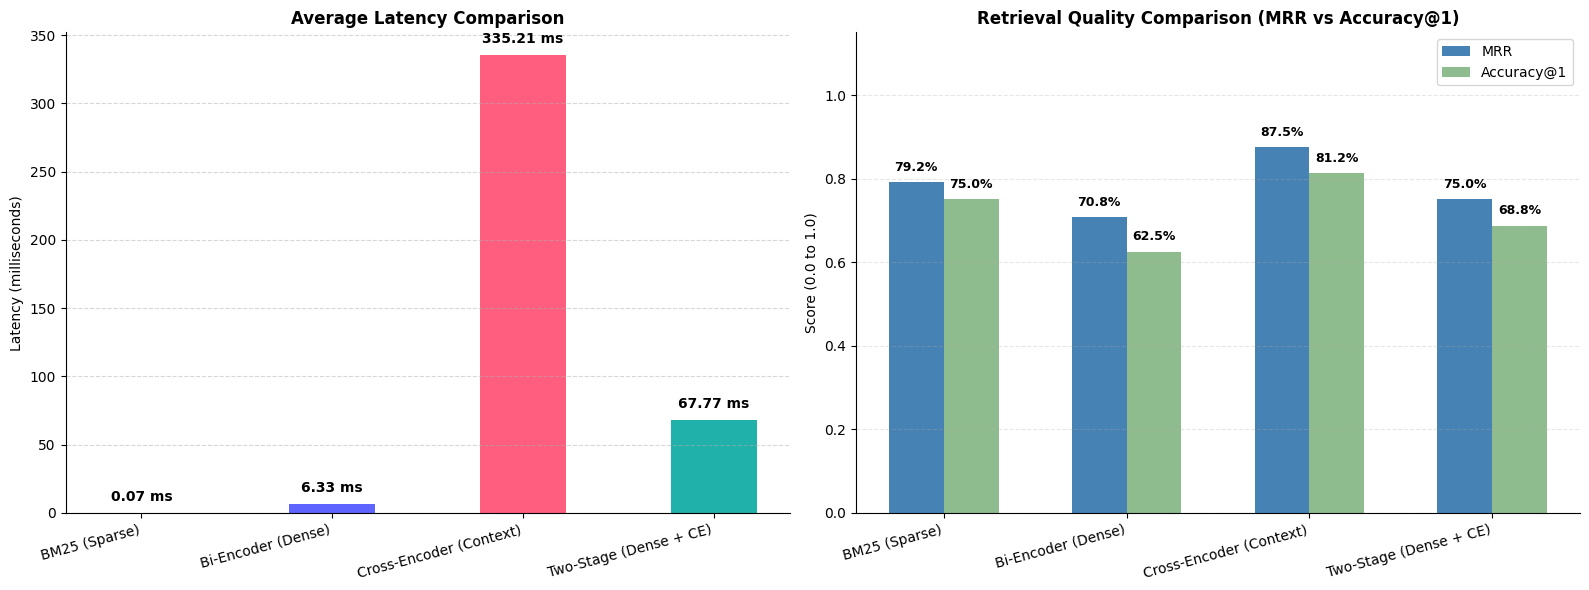


=== PERFORMANCE BY CATEGORY ===


In [19]:
import pandas as pd

df_summary = evaluation.compute_summary_report(bm25_res, dense_res, ce_res, two_stage_res)
print("\n=== COMPARISON SUMMARY ===")
display(df_summary)
# --- 4. VẼ BIỂU ĐỒ SO SÁNH TRỰC QUAN ---
evaluation.plot_comparisons(df_summary)

# --- 5. Thống kê chi tiết hiệu năng theo từng Category ---
df_category = evaluation.compute_category_report(bm25_res, dense_res, ce_res, two_stage_res)
print("\n=== PERFORMANCE BY CATEGORY ===")
# Định dạng hiển thị đẹp mắt (mili-giây cho latency, % cho chất lượng)
styled_category = df_category.style.format(
    formatter=lambda x: f"{x:.2f} ms" if x > 1.0 else (f"{x*100:.1f}%" if pd.notna(x) else "N/A"),
    na_rep="N/A"
).background_gradient(cmap="Greens", axis=0, subset=["MRR", "Accuracy@1"])
display(styled_category)

In [21]:
import os
import pandas as pd

# --- 1. Gộp các kết quả thô của từng mô hình thành df_eval ---
df_eval = pd.DataFrame({
    "ID": [item["id"] for item in bm25_res],
    "Category": [item["category"] for item in bm25_res],
    "Query": [item["query"] for item in bm25_res],
    "Expected_Idx": [item["expected_chunk_id"] for item in bm25_res],
    
    "BM25_Idx": [item["retrieved_index"] for item in bm25_res],
    "BM25_Latency_ms": [item["latency_ms"] for item in bm25_res],
    "BM25_RR": [item["rr"] for item in bm25_res],
    "BM25_Hit": [item["hit"] for item in bm25_res],
    
    "Dense_Idx": [item["retrieved_index"] for item in dense_res],
    "Dense_Latency_ms": [item["latency_ms"] for item in dense_res],
    "Dense_RR": [item["rr"] for item in dense_res],
    "Dense_Hit": [item["hit"] for item in dense_res],
    
    "CE_Idx": [item["retrieved_index"] for item in ce_res],
    "CE_Latency_ms": [item["latency_ms"] for item in ce_res],
    "CE_RR": [item["rr"] for item in ce_res],
    "CE_Hit": [item["hit"] for item in ce_res],
})

# Nếu có chạy Two-Stage, gộp thêm dữ liệu Two-Stage vào bảng chung
if 'two_stage_res' in locals() and two_stage_res is not None:
    df_eval["TS_Idx"] = [item["retrieved_index"] for item in two_stage_res]
    df_eval["TS_Latency_ms"] = [item["latency_ms"] for item in two_stage_res]
    df_eval["TS_RR"] = [item["rr"] for item in two_stage_res]
    df_eval["TS_Hit"] = [item["hit"] for item in two_stage_res]


# --- 2. Tạo thư mục và tiến hành lưu file ---
output_dir = "data/evaluation_results"
os.makedirs(output_dir, exist_ok=True)

# Lưu bảng kết quả chi tiết từng câu hỏi (20 câu hỏi x các mô hình)
detailed_file = os.path.join(output_dir, "detailed_results.csv")
df_eval.to_csv(detailed_file, index=False, encoding="utf-8-sig")

# Lưu bảng tổng quan hiệu năng các mô hình
summary_file = os.path.join(output_dir, "overall_summary.csv")
df_summary.to_csv(summary_file, index=False, encoding="utf-8-sig")

# Lưu bảng thống kê chi tiết theo từng Category
category_file = os.path.join(output_dir, "category_breakdown.csv")
df_category.to_csv(category_file, index=True, encoding="utf-8-sig")

print("=== SAVE RESULTS SUCCESSFUL ===")
print(f"1. Detailed results saved to: {detailed_file}")
print(f"2. Overall summary saved to:  {summary_file}")
print(f"3. Category breakdown saved to: {category_file}")


=== SAVE RESULTS SUCCESSFUL ===
1. Detailed results saved to: data/evaluation_results\detailed_results.csv
2. Overall summary saved to:  data/evaluation_results\overall_summary.csv
3. Category breakdown saved to: data/evaluation_results\category_breakdown.csv
